In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

#For making a synthetic dataset:
from sklearn.datasets import make_classification

#Models
from sklearn.linear_model import LogisticRegression, SGDClassifier

#Model accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import cross_val_score

import plotly.express as px

In [373]:
X, y = make_classification(n_samples=1000, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=1)

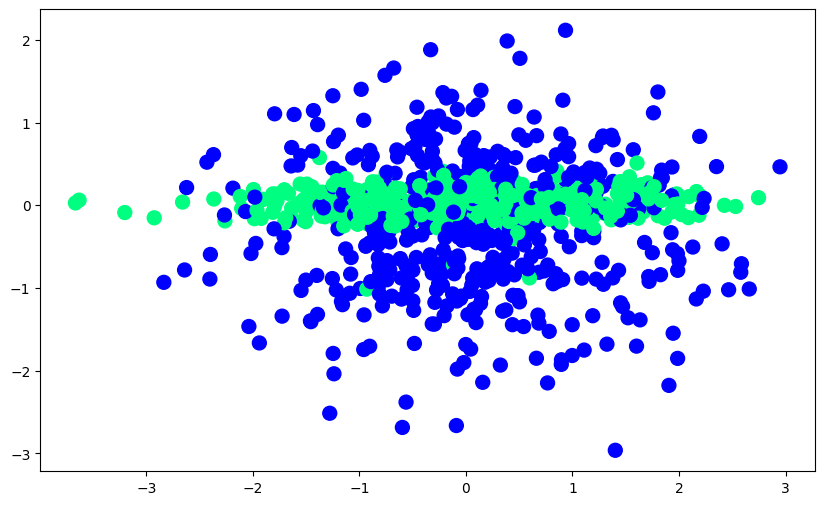

In [374]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1], c=y, cmap='winter', s=100)

In [375]:
X_train, X_test, y_train, y_test = train_test_split(X, y , random_state = 13, test_size = 0.2)

In [376]:
class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=100, type="step", cut_off = 0.0) -> None:
        self.epochs = epochs
        self.weights = np.array([])
        self.coef_ = np.array([])
        self.intercept_ = np.array([])
        self.learning_rate = learning_rate
        self.type = type
        self.cut_off = cut_off

    def converter(self, z):
        if self.type=="step":
            return np.where(z > self.cut_off, 1, 0)
        if self.type=="sigmoid":
            return np.where(z >= 0, 1 / (1 + np.exp(-z)), np.exp(z) / (1 + np.exp(z)))
    
    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        X = np.insert(X, 0, 1, axis=1)
        self.weights = np.random.rand(X.shape[1])
        
        for _ in range(self.epochs):
            random_row =  np.random.randint(0, X.shape[0])
            
            y_pred = self.converter(X[random_row] @ self.weights)

            # Weights_new := Weights_old - learning_rate * gradient
            self.weights += self.learning_rate * (y[random_row] - y_pred) * X[random_row]

        self.intercept_ = self.weights[0]
        self.coef_ = self.weights[1:]

    def predict(self, X):
        X = np.insert(X, 0, 1, axis=1)
        y_pred = X @ self.weights
        return np.where(self.converter(y_pred) > self.cut_off, 1, 0)


In [377]:
my_perceptron1 = Perceptron(learning_rate=0.01, epochs=2000)
my_perceptron1.fit(X_train, y_train)
print(f"Step functionIntercept weights {my_perceptron1.weights}")

Step functionIntercept weights [-0.00067302 -0.01106381 -0.00213953]


In [378]:
#CampusX Implementation
def gd(X,y):    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5
    
    for i in range(5000):
        y_hat = sigmoid(np.dot(X,weights))
        weights += lr*(np.dot((y-y_hat),X)/X.shape[0])
        
    return weights[1:],weights[0]
        

def sigmoid(z):
    return 1/(1 + np.exp(-z))

coef_,intercept_ = gd(X_train,y_train)

print(f"Step functionIntercept {intercept_} Coefficient {coef_}")

Step functionIntercept 0.10421152153149416 Coefficient [-0.14738373  0.8497629 ]


In [379]:
my_perceptron2 = Perceptron(learning_rate=0.001, epochs=2000, type="sigmoid", cut_off=0.5)
my_perceptron2.fit(X_train, y_train)
print(f"Sigmoid function weights{my_perceptron2.weights}")

Sigmoid function weights[ 0.06314974 -0.0240536   0.37064749]


In [380]:
from ctypes import ArgumentError


class MyLogisticRegression:
    def __init__(self, learning_rate=0.01, epochs=2000, solver="sgdclassifier", cut_off=0.5) -> None:
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.solver = solver
        self.cut_off = cut_off
        self.weights = np.array([])
        self.coef_ = np.array([])
        self.intercept_ = np.array([])

    def sigmoid(self, z):
        return np.where(z >= 0, 1 / (1 + np.exp(-z)), np.exp(z) / (1 + np.exp(z)))

    
    def fit(self, X, y):
        if isinstance(X, pd.DataFrame) and isinstance(y, pd.Series):
            X = X.to_numpy()
            y = y.to_numpy()

        X = np.asarray(X)
        y = np.asarray(y)

        X = np.insert(X, 0, 1, axis=1)

        self.weights = np.zeros(X.shape[1])

        if self.solver=="sgdclassifer":
            #for _ in range(self.epochs):
            #    random_row =  np.random.randint(0, rows)
            #    y_pred = self.sigmoid(X[random_row] @ self.weights)
            pass
            
        elif self.solver=="bgdclassifier":
            for _ in range(self.epochs):
                y_pred = self.sigmoid(X @ self.weights)
                graident = np.mean(-((y - y_pred) @ X))
                self.weights -=  self.learning_rate * graident

        else:
            raise ArgumentError
        
        self.intercept_ = self.weights[0]
        self.coef_ = self.weights[1:]
    
    def predict(self, X):
        X = np.insert(X, 0, 1, axis=1)
        y_pred = X @ self.weights
        return np.where(self.sigmoid(y_pred) > self.cut_off, 1, 0)
    
    def predict_proba(self, X):
        X = np.insert(X, 0, 1, axis=1)
        y_pred = X @ self.weights
        return self.sigmoid(y_pred)

In [381]:
my_lor = MyLogisticRegression(learning_rate=0.5, epochs=2000, cut_off=0.75, solver="bgdclassifier")
my_lor.fit(X_train, y_train)
print(f"Step function intercept {my_lor.intercept_} coefficient {my_lor.coef_}")

Step function intercept 1.1606430264654364 coefficient [1.16064303 1.16064303]


In [382]:
import copy

class IBMLogisticRegression():
    def __init__(self):
        self.losses = []
        self.train_accuracies = []

    def fit(self, x, y, epochs):
        x = self._transform_x(x)
        y = self._transform_y(y)

        self.weights = np.zeros(x.shape[1])
        self.bias = 0

        for i in range(epochs):
            x_dot_weights = np.matmul(self.weights, x.transpose()) + self.bias
            pred = self._sigmoid(x_dot_weights)
            loss = self.compute_loss(y, pred)
            error_w, error_b = self.compute_gradients(x, y, pred)
            self.update_model_parameters(error_w, error_b)

            pred_to_class = [1 if p > 0.5 else 0 for p in pred]
            self.train_accuracies.append(accuracy_score(y, pred_to_class))
            self.losses.append(loss)

    def compute_loss(self, y_true, y_pred):
        # binary cross entropy
        y_zero_loss = y_true * np.log(y_pred + 1e-9)
        y_one_loss = (1-y_true) * np.log(1 - y_pred + 1e-9)
        return -np.mean(y_zero_loss + y_one_loss)

    def compute_gradients(self, x, y_true, y_pred):
        # derivative of binary cross entropy
        difference =  y_pred - y_true
        gradient_b = np.mean(difference)
        gradients_w = np.matmul(x.transpose(), difference)
        gradients_w = np.array([np.mean(grad) for grad in gradients_w])

        return gradients_w, gradient_b

    def update_model_parameters(self, error_w, error_b):
        self.weights = self.weights - 0.1 * error_w
        self.bias = self.bias - 0.1 * error_b

    def predict(self, x):
        x_dot_weights = np.matmul(x, self.weights.transpose()) + self.bias
        probabilities = self._sigmoid(x_dot_weights)
        return [1 if p > 0.5 else 0 for p in probabilities]

    def _sigmoid(self, x):
        return np.array([self._sigmoid_function(value) for value in x])

    def _sigmoid_function(self, x):
        if x >= 0:
            z = np.exp(-x)
            return 1 / (1 + z)
        else:
            z = np.exp(x)
            return z / (1 + z)

    def _transform_x(self, x):
        x = copy.deepcopy(x)
        return x

    def _transform_y(self, y):
        y = copy.deepcopy(y)
        return y.reshape(y.shape[0], 1)

In [383]:
ibm_lor = IBMLogisticRegression()
ibm_lor.fit(X_train, y_train, epochs=1000)
print(f"Step functionIntercept {ibm_lor.bias} Coefficient {ibm_lor.weights}")

Step functionIntercept 3.8737194086111932 Coefficient [-3022.90477242  5186.93811306]


In [384]:
sklearn_lor = LogisticRegression(solver='sag', l1_ratio=0, max_iter=5000)
sklearn_lor.fit(X_train, y_train)
print(f"Step functionIntercept {sklearn_lor.intercept_} Coefficient {sklearn_lor.coef_}")
print(f"Step function intercept {my_lor.intercept_} coefficient {my_lor.coef_}")

Step functionIntercept [0.10291769] Coefficient [[-0.1465872   0.83402666]]
Step function intercept 1.1606430264654364 coefficient [1.16064303 1.16064303]


In [385]:
sklearn_sgdclassifier = SGDClassifier(penalty=None, learning_rate='constant', max_iter=5000, loss='log_loss')
sklearn_sgdclassifier.fit(X_train, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",5000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


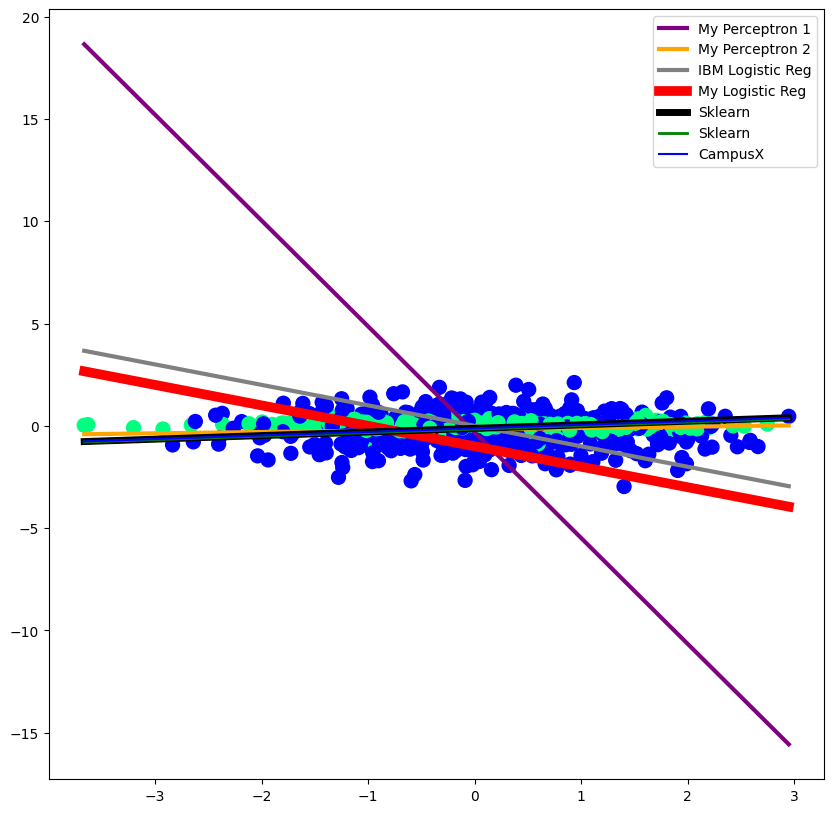

In [386]:
x_input = np.linspace(X[:,0].min(), X[:,0].max(), 100)

my_perceptron1_output = -(my_perceptron1.intercept_ +
       my_perceptron1.coef_[0] * x_input) / my_perceptron1.coef_[1]

my_perceptron2_output = -(my_perceptron2.intercept_ +
       my_perceptron2.coef_[0] * x_input) / my_perceptron2.coef_[1]

my_lor_output = -(my_lor.intercept_/ my_lor.coef_[1]) - (my_lor.coef_[0]/my_lor.coef_[1]  * x_input)

ibm_lor_output = -(ibm_lor.bias/ ibm_lor.weights[0]) - (ibm_lor.weights[0]/ibm_lor.weights[0] * x_input)

sklearn_lor_output = -(sklearn_lor.intercept_[0]/sklearn_lor.coef_[0][1]) - (sklearn_lor.coef_[0][0]/sklearn_lor.coef_[0][1] * x_input)

sklearn_sgdclassifier_output = -(sklearn_sgdclassifier.intercept_[0]/sklearn_sgdclassifier.coef_[0][1]) - (sklearn_sgdclassifier.coef_[0][0]/sklearn_sgdclassifier.coef_[0][1] * x_input)

y_input1 = -(coef_[0]/coef_[1])*x_input -(intercept_/coef_[1])

plt.figure(figsize=(10,10))
plt.scatter(X[:,0],X[:,1], c=y, cmap='winter', s=100)

plt.plot(x_input, my_perceptron1_output, color='purple', label='My Perceptron 1', linewidth=3)
plt.plot(x_input, my_perceptron2_output, color='orange', label='My Perceptron 2', linewidth=3)
plt.plot(x_input, ibm_lor_output, color='grey', label='IBM Logistic Reg', linewidth=3)
plt.plot(x_input, my_lor_output, color='red', label='My Logistic Reg',linewidth=7)
plt.plot(x_input, sklearn_lor_output, color='black', label='Sklearn', linewidth=5)
plt.plot(x_input, sklearn_sgdclassifier_output, color='green', label='Sklearn', linewidth=2)

plt.plot(x_input,y_input1,color='blue', label='CampusX')

plt.legend()
plt.show()

In [ ]:
import plotly.graph_objects as go 

fig = px.scatter_3d(x=X_train[:, 0], y=X_train[:, 1], z=y_train, color_discrete_sequence=['black'], labels=dict(x="0", y="1", z="Predicted Probability"))

# Set figure title and colors
fig.update_layout(title_text="Scatter 3D Plot for My Logistic Regression", scene = dict(xaxis=dict(backgroundcolor='white', color='black', gridcolor='lightgrey'), yaxis=dict(backgroundcolor='white',color='black', gridcolor='lightgrey'), zaxis=dict(backgroundcolor='white', color='black', gridcolor='lightgrey')))

# Update marker size
fig.update_traces(marker=dict(size=3))

xrange = np.linspace(X[:,0].min(), X[:,0].max(), 200)
yrange = np.linspace(X[:,1].min(), X[:,1].max(), 200)
xx, yy = np.meshgrid(xrange, yrange)
grid = np.c_[xx.ravel(), yy.ravel()]

# Add prediction plane
probs = my_lor.predict_proba(grid)
probs = probs.reshape(xx.shape)

mask_0 = y_test < my_lor.cut_off
mask_1 = y_test > my_lor.cut_off 


fig.add_traces(go.Surface(x=xx, y=yy, z=probs, name='LR Prediction', colorscale=px.colors.sequential.Aggrnyl_r))

fig.add_traces(go.Scatter3d(x=X_test[:, 0][mask_1], y=X_test[:, 1][mask_1], z=probs[mask_1], name='1', showlegend=False, mode = 'markers', opacity=0.9, marker=dict(color='limegreen', size=3)))

fig.add_traces(go.Scatter3d(x=X_test[:, 0][mask_0], y=X_test[:, 1][mask_0], z=probs[mask_0], name='0', showlegend=False, mode = 'markers', opacity=0.9, marker=dict(color='blue', size=3)))

fig.show()

[0.00144995 0.00150689 0.00156607 ... 0.99905317 0.99908897 0.99912342]


In [416]:
import plotly.graph_objects as go 

fig = px.scatter_3d(x=X_train[:, 0], y=X_train[:, 1], z=y_train, color_discrete_sequence=['black'], labels=dict(x="0", y="1", z="Predicted Probability"))

# Set figure title and colors
fig.update_layout(title_text="Scatter 3D Plot for Scikit-Learn LR", scene = dict(xaxis=dict(backgroundcolor='white', color='black', gridcolor='lightgrey'), yaxis=dict(backgroundcolor='white',color='black', gridcolor='lightgrey'), zaxis=dict(backgroundcolor='white', color='black', gridcolor='lightgrey')))

# Update marker size
fig.update_traces(marker=dict(size=3))

xrange = np.linspace(X[:,0].min(), X[:,0].max(), 200)
yrange = np.linspace(X[:,1].min(), X[:,1].max(), 200)
xx, yy = np.meshgrid(xrange, yrange)
grid = np.c_[xx.ravel(), yy.ravel()]

# Add prediction plane
probs = sklearn_lor.predict_proba(grid)
probs = probs[:, 1]
probs = probs.reshape(xx.shape)

mask_0 = y_test < my_lor.cut_off
mask_1 = y_test > my_lor.cut_off 


fig.add_traces(go.Surface(x=xx, y=yy, z=probs, name='LR Prediction', colorscale=px.colors.sequential.Aggrnyl_r))

fig.add_traces(go.Scatter3d(x=X_test[:, 0][mask_1], y=X_test[:, 1][mask_1], z=probs[mask_1], name='1', showlegend=False, mode = 'markers', opacity=0.9, marker=dict(color='limegreen', size=3)))

fig.add_traces(go.Scatter3d(x=X_test[:, 0][mask_0], y=X_test[:, 1][mask_0], z=probs[mask_0], name='0', showlegend=False, mode = 'markers', opacity=0.9, marker=dict(color='blue', size=3)))

fig.show()

#### Accuracy:

In [388]:
my_perceptron1_accuracy_score = accuracy_score(y_test, my_perceptron1.predict(X_test))
print("Percpetron 1 accuracy_score:\n", my_perceptron1_accuracy_score)

my_perceptron2_accuracy_score = accuracy_score(y_test, my_perceptron2.predict(X_test))
print("Percpetron 2 accuracy_score:\n", my_perceptron2_accuracy_score)

ibm_lor_accuracy_score = accuracy_score(y_test, ibm_lor.predict(X_test))
print("IBM Logistic Regression accuracy_score:\n", ibm_lor_accuracy_score)

my_lor_accuracy_score = accuracy_score(y_test, my_lor.predict(X_test))
print("My Logistic Regression accuracy_score:\n", my_lor_accuracy_score)

sklearn_lor_accuracy_score = accuracy_score(y_test, sklearn_lor.predict(X_test))
print("Scikit Logistic Regression accuracy_score:\n", sklearn_lor_accuracy_score)

Percpetron 1 accuracy_score:
 0.48
Percpetron 2 accuracy_score:
 0.675
IBM Logistic Regression accuracy_score:
 0.56
My Logistic Regression accuracy_score:
 0.56
Scikit Logistic Regression accuracy_score:
 0.67


#### Precision

In [389]:
my_perceptron1_precision_score = precision_score(y_test, my_perceptron1.predict(X_test))
print("Percpetron 1 precision_score:\n", my_perceptron1_precision_score)

my_perceptron2_precision_score = precision_score(y_test, my_perceptron2.predict(X_test))
print("Percpetron 2 precision_score:\n", my_perceptron2_precision_score)

ibm_lor_precision_score = precision_score(y_test, ibm_lor.predict(X_test))
print("IBM Logistic Regression precision_score:\n", ibm_lor_precision_score)

my_lor_precision_score = precision_score(y_test, my_lor.predict(X_test))
print("My Logistic Regression precision_score:\n", my_lor_precision_score)

sklearn_lor_precision_score = precision_score(y_test, sklearn_lor.predict(X_test))
print("Scikit Logistic Regression precision_score:\n", sklearn_lor_precision_score)

Percpetron 1 precision_score:
 0.4583333333333333
Percpetron 2 precision_score:
 0.6099290780141844
IBM Logistic Regression precision_score:
 0.5384615384615384
My Logistic Regression precision_score:
 0.54
Scikit Logistic Regression precision_score:
 0.6171875


#### Recall Score:

In [390]:
my_perceptron1_recall_score = recall_score(y_test, my_perceptron1.predict(X_test))
print("Percpetron 1 recall_score:\n", my_perceptron1_recall_score)

my_perceptron2_recall_score = recall_score(y_test, my_perceptron2.predict(X_test))
print("Percpetron 2 recall_score:\n", my_perceptron2_recall_score)

ibm_lor_recall_score = recall_score(y_test, ibm_lor.predict(X_test))
print("IBM Logistic Regression recall_score:\n", ibm_lor_recall_score)

my_lor_recall_score = recall_score(y_test, my_lor.predict(X_test))
print("My Logistic Regression recall_score:\n", my_lor_recall_score)

sklearn_lor_recall_score = recall_score(y_test, sklearn_lor.predict(X_test))
print("Scikit Logistic Regression recall_score:\n", sklearn_lor_recall_score)

Percpetron 1 recall_score:
 0.4583333333333333
Percpetron 2 recall_score:
 0.8958333333333334
IBM Logistic Regression recall_score:
 0.5833333333333334
My Logistic Regression recall_score:
 0.5625
Scikit Logistic Regression recall_score:
 0.8229166666666666


In [391]:
my_perceptron1_f1_score = f1_score(y_test, my_perceptron1.predict(X_test), average="macro")
print("Percpetron 1 f1_score macro:\n", my_perceptron1_f1_score)

my_perceptron2_f1_score = f1_score(y_test, my_perceptron2.predict(X_test), average="macro")
print("Percpetron 2 f1_score macro:\n", my_perceptron2_f1_score)

ibm_lor_f1_score = f1_score(y_test, ibm_lor.predict(X_test), average="macro")
print("IBM Logistic Regression f1_score macro:\n", ibm_lor_f1_score)

my_lor_f1_score = f1_score(y_test, my_lor.predict(X_test), average="macro")
print("My Logistic Regression f1_score macro:\n", my_lor_f1_score)

sklearn_lor_f1_score = f1_score(y_test, sklearn_lor.predict(X_test), average="macro")
print("Scikit Logistic Regression f1_score macro:\n", sklearn_lor_f1_score)

Percpetron 1 f1_score macro:
 0.47916666666666663
Percpetron 2 f1_score macro:
 0.6634826952447517
IBM Logistic Regression f1_score macro:
 0.56
My Logistic Regression f1_score macro:
 0.5598239295718287
Scikit Logistic Regression f1_score macro:
 0.6651785714285714


In [392]:
my_perceptron1_f1_score = f1_score(y_test, my_perceptron1.predict(X_test), average="weighted")
print("Percpetron 1 f1_score weighted:\n", my_perceptron1_f1_score)

my_perceptron2_f1_score = f1_score(y_test, my_perceptron2.predict(X_test), average="weighted")
print("Percpetron 2 f1_score weighted:\n", my_perceptron2_f1_score)

ibm_lor_f1_score = f1_score(y_test, ibm_lor.predict(X_test), average="weighted")
print("IBM Logistic Regression f1_score weighted:\n", ibm_lor_f1_score)

my_lor_f1_score = f1_score(y_test, my_lor.predict(X_test), average="weighted")
print("My Logistic Regression f1_score weighted:\n", my_lor_f1_score)

sklearn_lor_f1_score = f1_score(y_test, sklearn_lor.predict(X_test), average="weighted")
print("Scikit Logistic Regression f1_score weighted:\n", sklearn_lor_f1_score)

Percpetron 1 f1_score weighted:
 0.48
Percpetron 2 f1_score weighted:
 0.6609924671895628
IBM Logistic Regression f1_score weighted:
 0.56
My Logistic Regression f1_score weighted:
 0.5601760704281712
Scikit Logistic Regression f1_score weighted:
 0.6635714285714286


Percpetron 1 confusion_matrix:
 [[52 52]
 [52 44]]
Percpetron 2 confusion_matrix:
 [[49 55]
 [10 86]]
IBM Logistic Regression confusion_matrix:
 [[56 48]
 [40 56]]
My Logistic Regression confusion matrix:
 [[58 46]
 [42 54]]
Scikit-Learn Logistic Regression confusion_matrix:
 [[55 49]
 [17 79]]


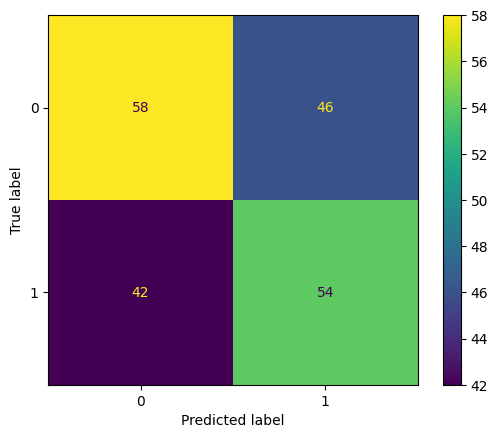

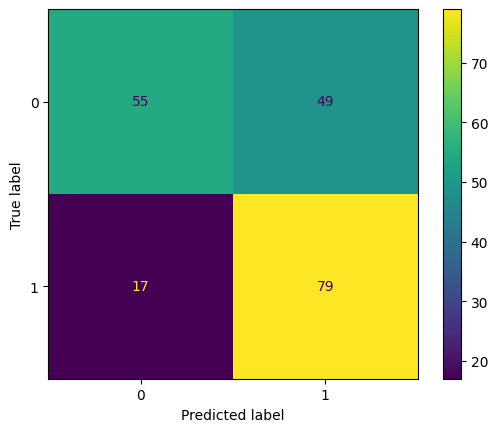

In [393]:
my_perceptron1_confusion_matrix = confusion_matrix(y_test, my_perceptron1.predict(X_test))
print("Percpetron 1 confusion_matrix:\n", my_perceptron1_confusion_matrix)

my_perceptron2_confusion_matrix = confusion_matrix(y_test, my_perceptron2.predict(X_test))
print("Percpetron 2 confusion_matrix:\n", my_perceptron2_confusion_matrix)

ibm_lor_confusion_matrix = confusion_matrix(y_test, ibm_lor.predict(X_test))
print("IBM Logistic Regression confusion_matrix:\n", ibm_lor_confusion_matrix)

my_lor_confusion_matrix = confusion_matrix(y_test, my_lor.predict(X_test))
print("My Logistic Regression confusion matrix:\n", my_lor_confusion_matrix)

sklearn_lor_confusion_matrix = confusion_matrix(y_test, sklearn_lor.predict(X_test))
print("Scikit-Learn Logistic Regression confusion_matrix:\n", sklearn_lor_confusion_matrix)

my_lor_confusion_matrix_display = ConfusionMatrixDisplay(my_lor_confusion_matrix)
my_lor_confusion_matrix_display.plot()
plt.show()


sklearn_lor_confusion_matrix_display = ConfusionMatrixDisplay(sklearn_lor_confusion_matrix)
sklearn_lor_confusion_matrix_display.plot()
plt.show()

In [394]:
my_perceptron1_classification_report = classification_report(y_test, my_perceptron1.predict(X_test))
print("Percpetron 1 classification_report:\n", my_perceptron1_classification_report)

my_perceptron2_classification_report = classification_report(y_test, my_perceptron2.predict(X_test))
print("Percpetron 2 classification_report:\n", my_perceptron2_classification_report)

ibm_lor_classification_report = classification_report(y_test, ibm_lor.predict(X_test))
print("IBM Logistic Regression classification_report:\n", ibm_lor_classification_report)

my_lor_classification_report = classification_report(y_test, my_lor.predict(X_test))
print("My Logistic Regression classification_report:\n", my_lor_classification_report)

sklearn_lor_classification_report = classification_report(y_test, sklearn_lor.predict(X_test))
print("Scikit-Learn Logistic Regression classification_report:\n", sklearn_lor_classification_report)

Percpetron 1 classification_report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50       104
           1       0.46      0.46      0.46        96

    accuracy                           0.48       200
   macro avg       0.48      0.48      0.48       200
weighted avg       0.48      0.48      0.48       200

Percpetron 2 classification_report:
               precision    recall  f1-score   support

           0       0.83      0.47      0.60       104
           1       0.61      0.90      0.73        96

    accuracy                           0.68       200
   macro avg       0.72      0.68      0.66       200
weighted avg       0.72      0.68      0.66       200

IBM Logistic Regression classification_report:
               precision    recall  f1-score   support

           0       0.58      0.54      0.56       104
           1       0.54      0.58      0.56        96

    accuracy                           0.56       200
   mac

In [402]:
#Threshold is also called cutoff value
fpr, tpr, thresholds = roc_curve(y_test, my_lor.predict_proba(X_test))

In [403]:
roc_auc_score(y_test, my_lor.predict_proba(X_test))

0.5245392628205128

In [397]:
import plotly.graph_objects as go

# Generate a trace for ROC curve
trace0 = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name='ROC curve'
)

# Only label every nth point to avoid cluttering
n = 10
indices = np.arange(len(thresholds)) % n == 0  # Choose indices where index mod n is 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={thr:.2f}" for thr in thresholds[indices]],
    textposition='top center'
)

# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=False
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()

In [398]:
# Assume that fpr, tpr, thresholds have already been calculated
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print("Optimal threshold is:", optimal_threshold)

Optimal threshold is: 0.7462141987281695


In [399]:
X.shape

(1000, 2)

In [400]:
auc(fpr, tpr)

0.5245392628205128

In [401]:
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Assuming that X_train, X_test, y_train, y_test are already defined

# SVM requires feature scaling for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_scores = lr_model.predict_proba(X_test)[:,1]

# SVM model
svm_model = SVC(probability=True)
svm_model.fit(X_train_scaled, y_train)
svm_scores = svm_model.predict_proba(X_test_scaled)[:,1]

# Generate ROC curve data for logistic regression model
lr_fpr, lr_tpr, lr_thresholds = roc_curve(y_test, lr_scores)
lr_auc = roc_auc_score(y_test, lr_scores)

# Generate ROC curve data for SVM model
svm_fpr, svm_tpr, svm_thresholds = roc_curve(y_test, svm_scores)
svm_auc = roc_auc_score(y_test, svm_scores)

# Generate a trace for the Logistic Regression ROC curve
trace0 = go.Scatter(
    x=lr_fpr,
    y=lr_tpr,
    mode='lines',
    name=f'Logistic Regression (Area = {lr_auc:.2f})'
)

# Generate a trace for the SVM ROC curve
trace1 = go.Scatter(
    x=svm_fpr,
    y=svm_tpr,
    mode='lines',
    name=f'SVM (Area = {svm_auc:.2f})'
)

# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()
